In [1]:
import numpy as np
from os import listdir

from ExistingAlgorithms.Plot import plot_traces
from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.decibels import file_name_table_npy, decibel_table_npy
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture
from AutoencoderAPI.utils.confidence import confidence
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.manifold import TSNE
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter

In [2]:
signal_size = 30_000
path_train = 'Datasets/SNSPD/Paderborn/data/'
path_model = 'grid-search-SNSPD Triplet 4/run 01/fold 0'#'run-2024-01-30-17-42/fold 0'#'grid-search-SNSPD param 4/run 09/fold 0'
mean_model, std_model = load_mean_std(path_model)

#X_train = np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::2, 3250:4500] for fileName in listdir(path_train)[::2]])
#X_train = (X_train - mean_model)/std_model
#X_zeros = X_train[np.min(X_train, axis=1) >= 1.6]
#X_train = X_train[np.min(X_train, axis=1) < -0.5]
#X_train = X_train[np.max(X_train, axis=1) > 1]

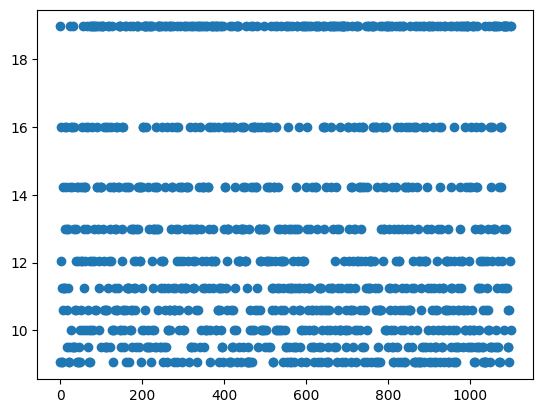

In [3]:
x = np.load('Datasets/SNSPD/Paderborn/db_shuffled.npy')
plt.scatter(range(len(x)), x)
plt.show()

# Poissonian statistics for t-SNE

## Load

In [ ]:
X, decibel_samples, decibel_zeros = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', #, decibel_zeros
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)

In [ ]:
#method = TSNE(n_components=2, perplexity=500)
#X_l = method.fit_transform(X)
#np.save("MetricLog/Metric_SNSPD/temp_tsne_SNSPD500_2D",X_l)

In [ ]:
X_l = np.load("MetricLog/Metric_SNSPD/temp_tsne_SNSPD500_2D.npy")

In [ ]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4).fit(X_l)
labels = gmm.predict(X_l)
plt.scatter(X_l[:, 0], X_l[:, 1],s=1, c=labels,alpha=0.005, cmap='viridis')

In [ ]:
n = 5
colors = plt.cm.jet(np.linspace(0,1,n))

for key in range(4):

    condition = labels == key
    X_ = X[condition]
    labels_ = labels[condition]

    plt.plot(np.mean(X_, axis=0), c=colors[key], label=f'{key}')

plt.show()

## Confidence

In [ ]:
decibel = []
g2 = []
average = []


X_l = np.load("MetricLog/Metric_SNSPD/temp_tsne_SNSPD2000_.npy")
X_l = (X_l-np.min(X_l)) / (np.max(X_l)-np.min(X_l))

conf = confidence(X_l,
                bw = [0.066], 
                number_cluster = 5,
                bins_plot = 500,
                density_kernel='cosine',
                flip = True, 
                skip = 10)

labels = conf.labels
bw_list = [0.008]*10#[0.07, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06]
min_prob_list = [5]*10#[0.01, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.045, 0.045, 0.045]

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key
    zeros_number = len(decibel_zeros[decibel_zeros == key])

    conf.fit(X_l[condition],
            bw = [bw_list[index]], 
            number_cluster = min_prob_list[index],
            bins_plot = 500,
            density_kernel='cosine',
            flip = True, 
            skip = 0,
            scaling=30,
            label_dB=key)
    
    #labels_ = labels[condition]
    labels_ = np.concatenate([labels[condition], np.zeros(zeros_number)])

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

## Plot

In [ ]:
conf.plot_all_confidence()
conf.plot_all_density()
conf.plot_total_density()
conf.plot_mean_cluster()

# dB evaluation

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB/10 )

In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -10], [1e4, 10]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt))
plt.scatter(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.show()
print(popt)

In [ ]:
import numpy.random as npr

average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 30_000) for i in average])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poissonian statistics for PCA

## Load

In [3]:
X, decibel_samples, decibel_zeros = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', 
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)#, decibel_zeros

condition = np.min(X, axis=1) < -1.5
X = X[condition]
decibel_samples = decibel_samples[condition]
#condition = np.max(X, axis=1) > 0
#X = X[condition]
#decibel_samples = decibel_samples[condition]

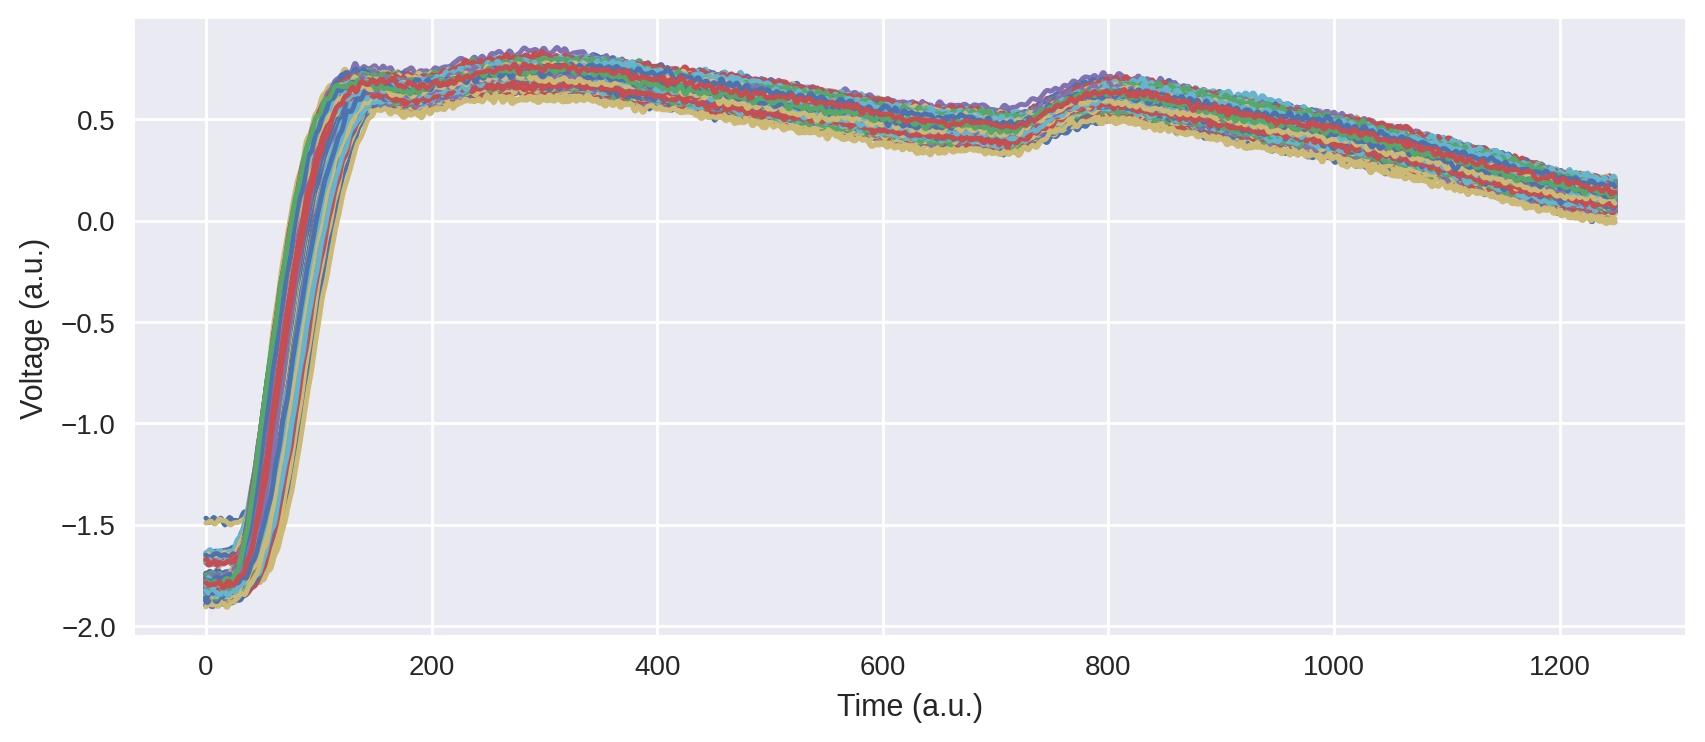

In [5]:
plot_traces(X)

## Confidence

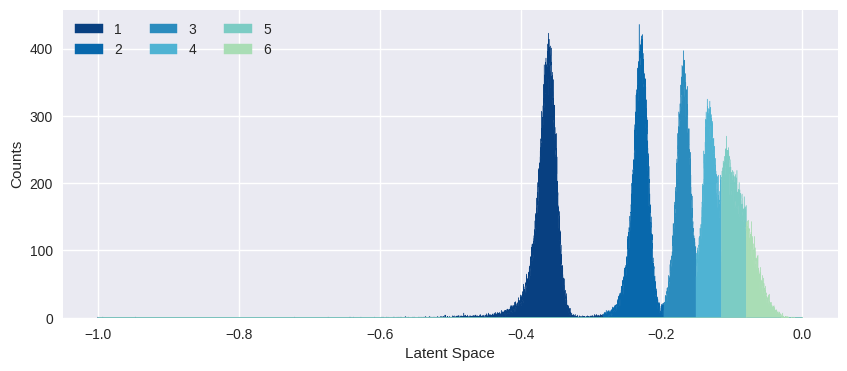

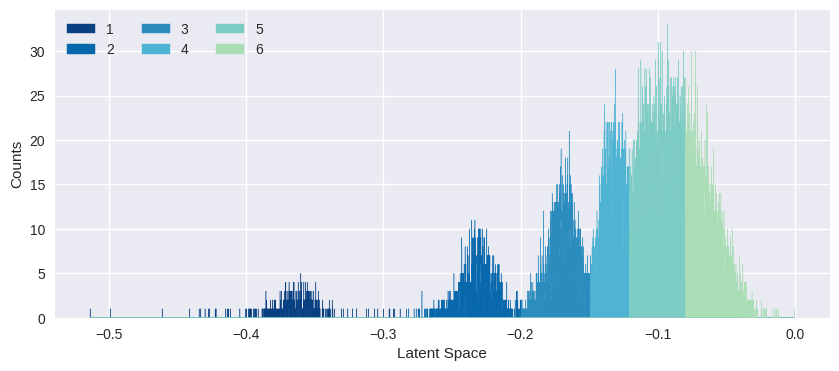

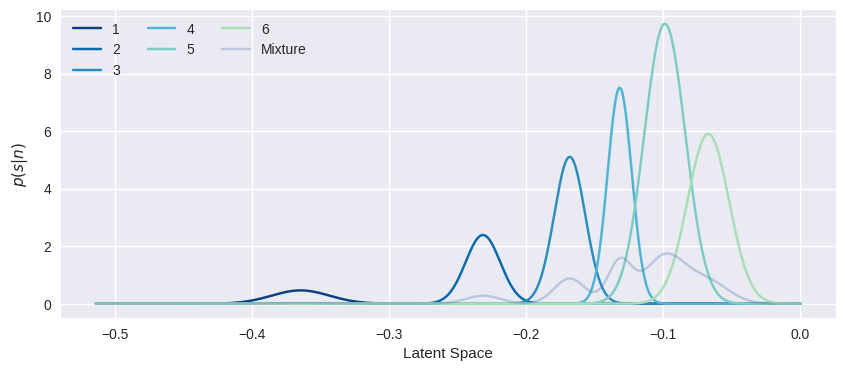

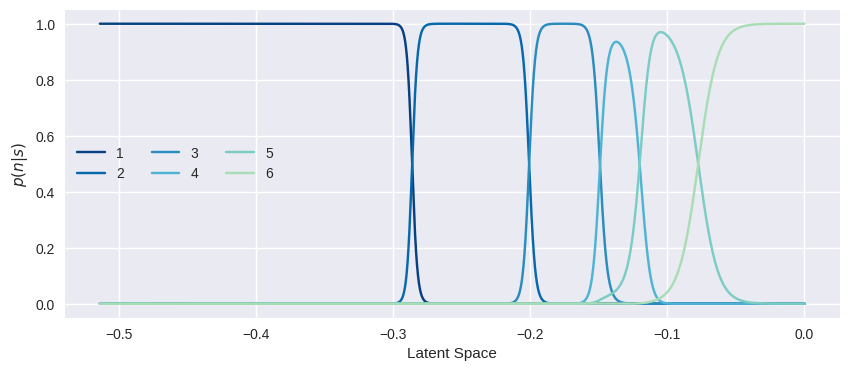

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


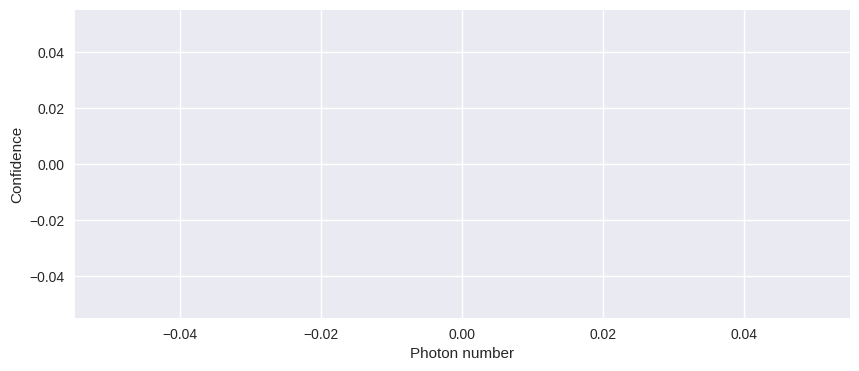

9.05
5.32700220074634


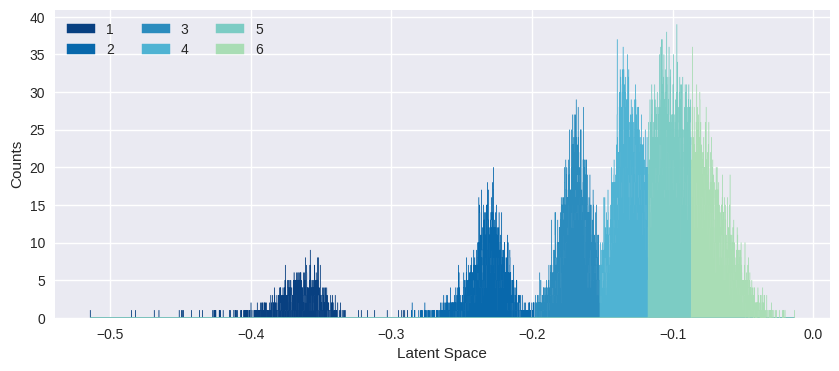

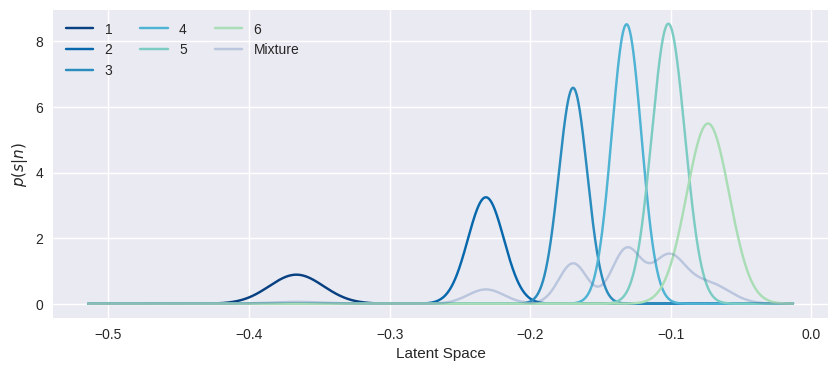

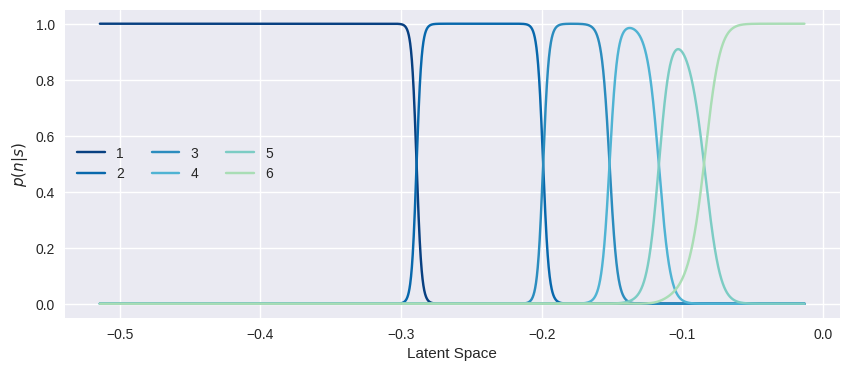

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


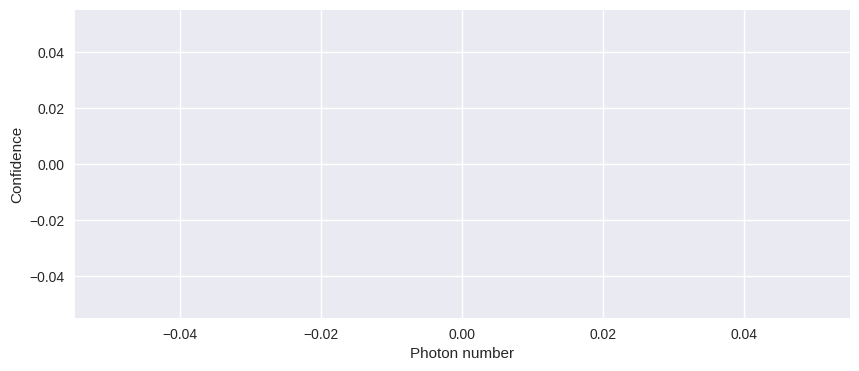

9.5
4.999713343844059


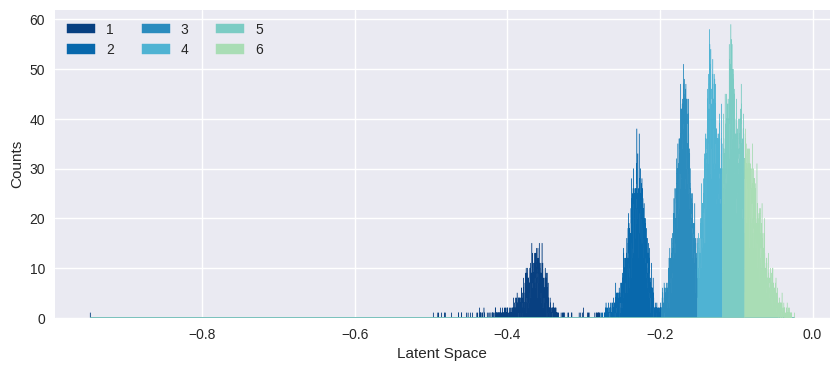

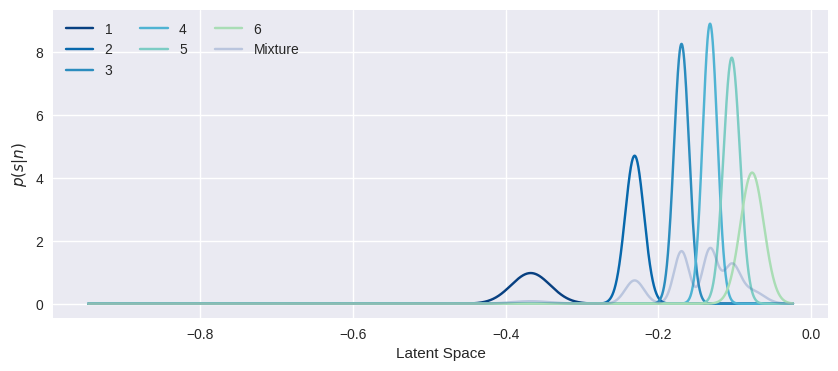

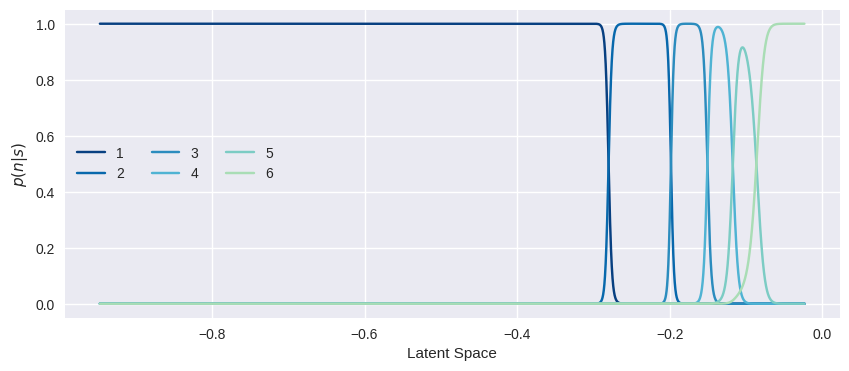

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


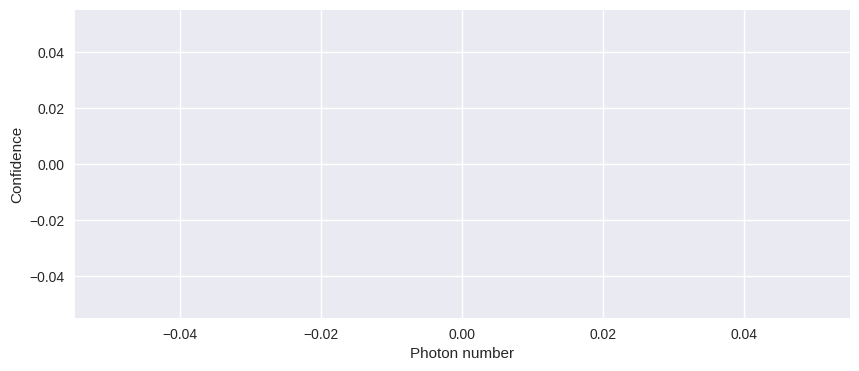

10.01
4.658545047997224


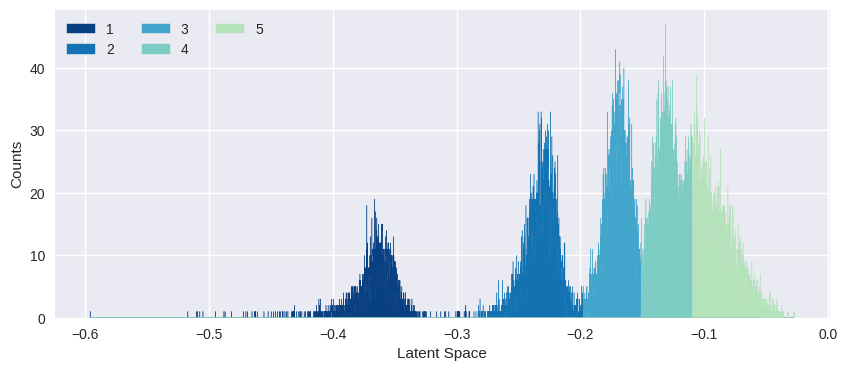

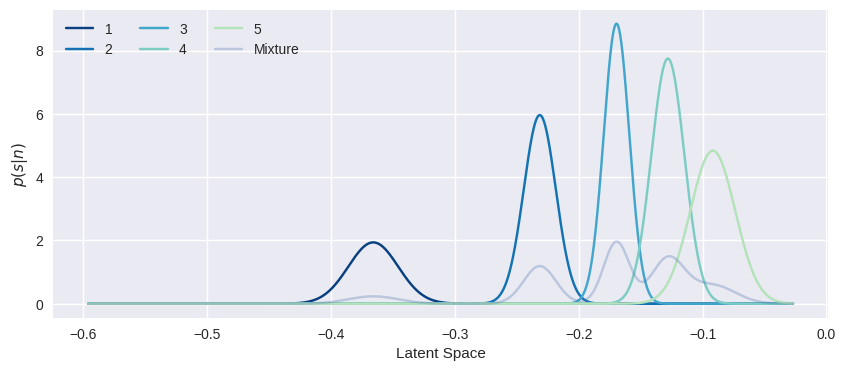

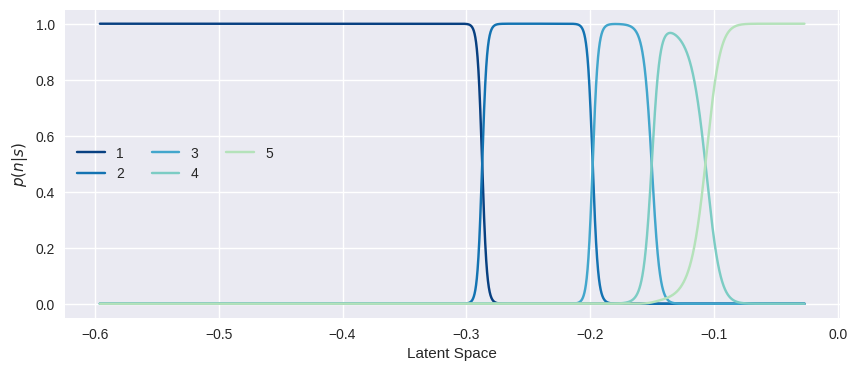

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


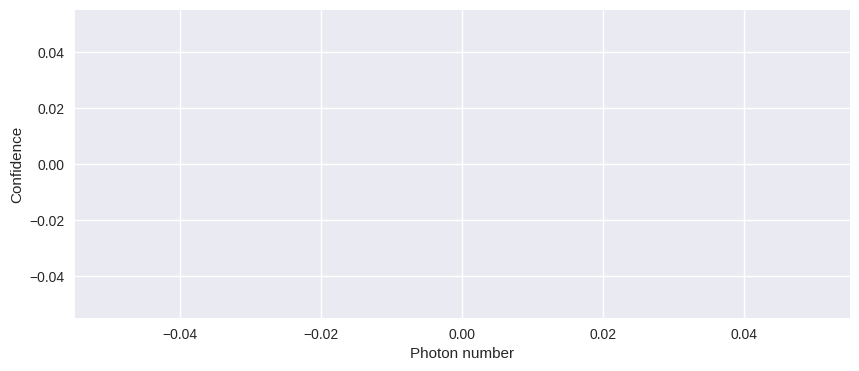

10.59
4.261963641224435


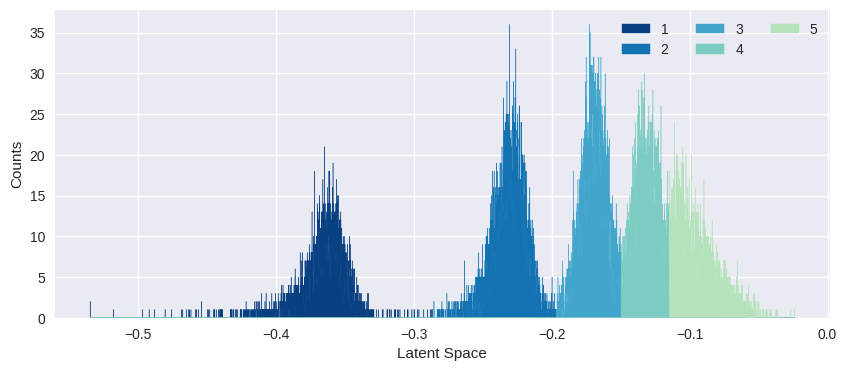

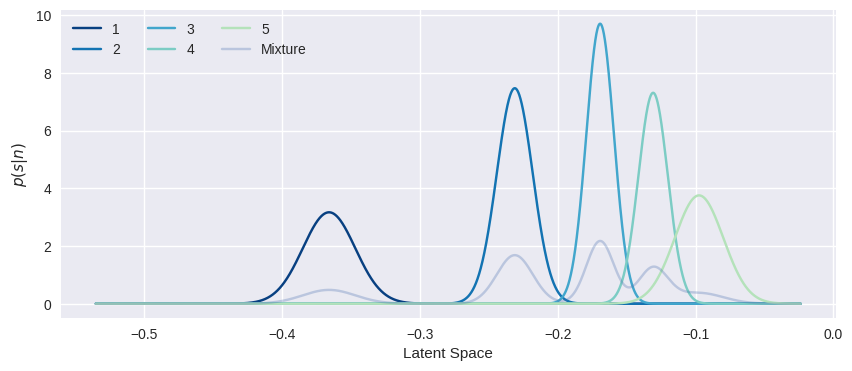

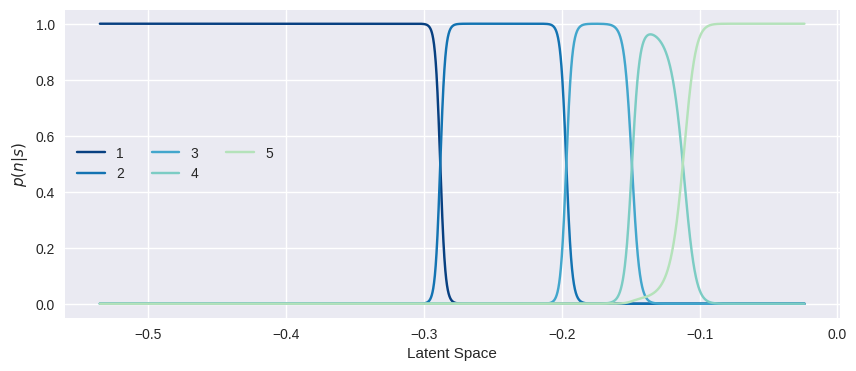

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


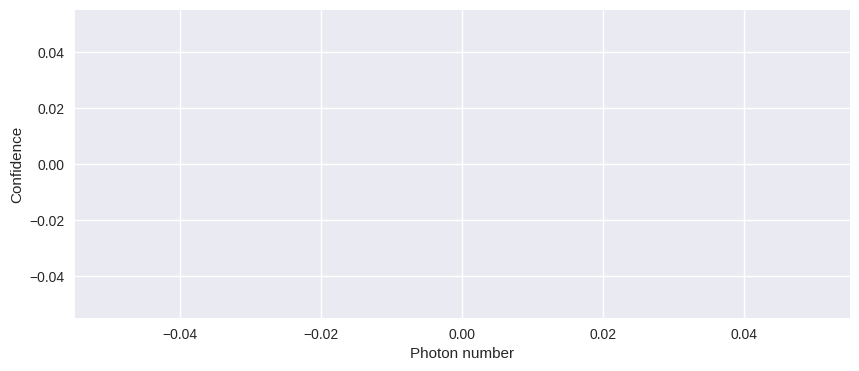

11.25
3.808344354935674


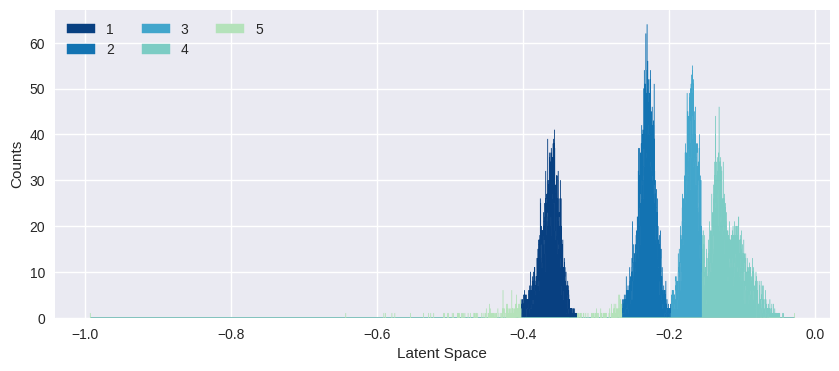

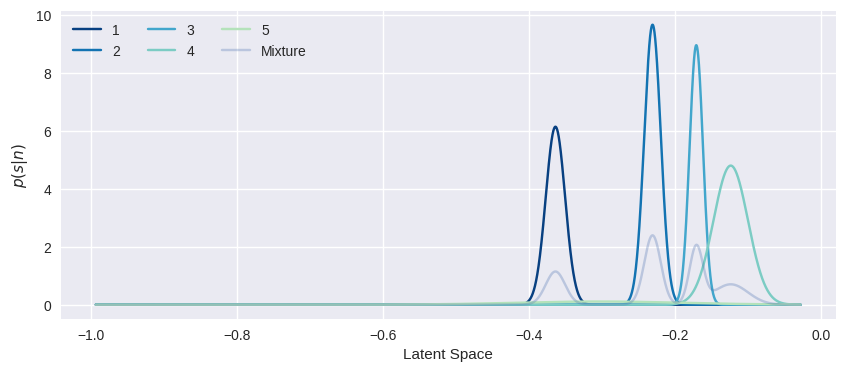

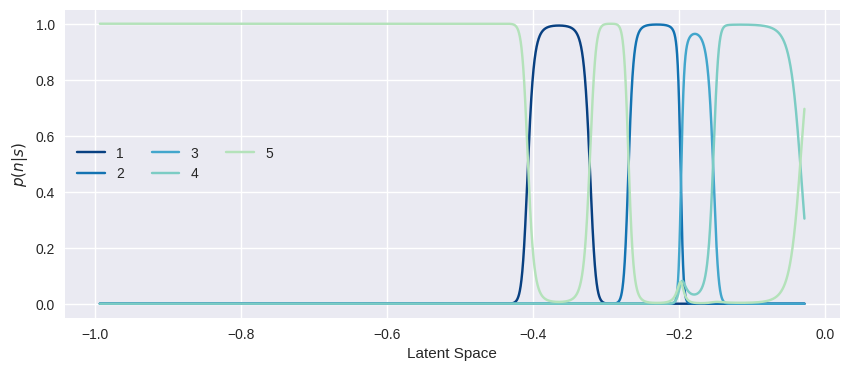

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integra

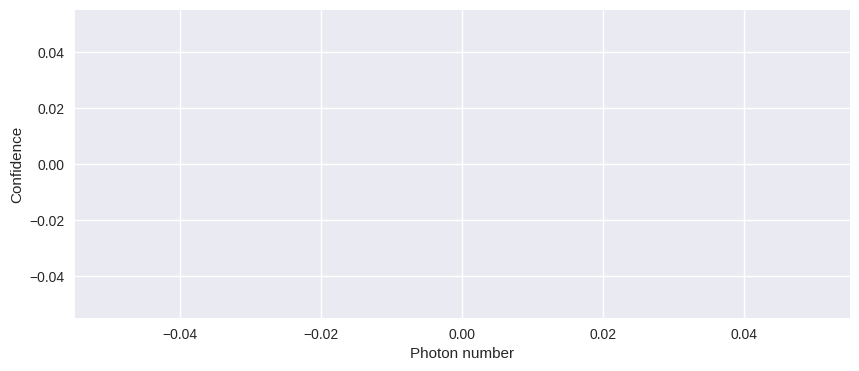

12.04
3.3705172897383497


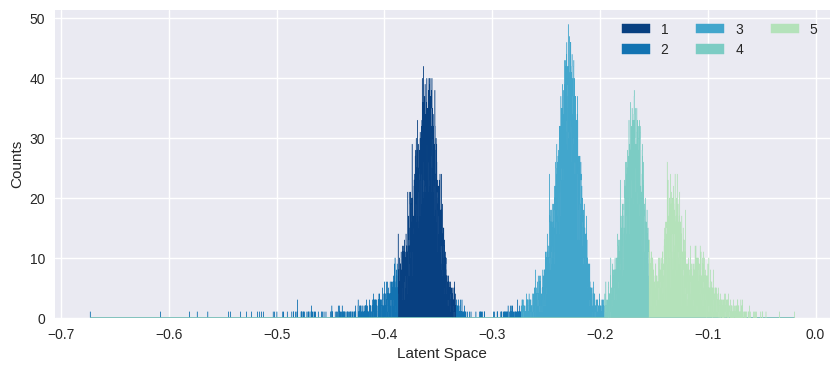

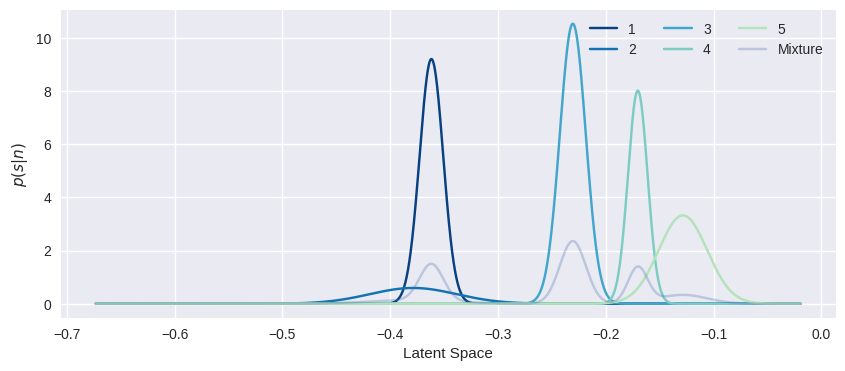

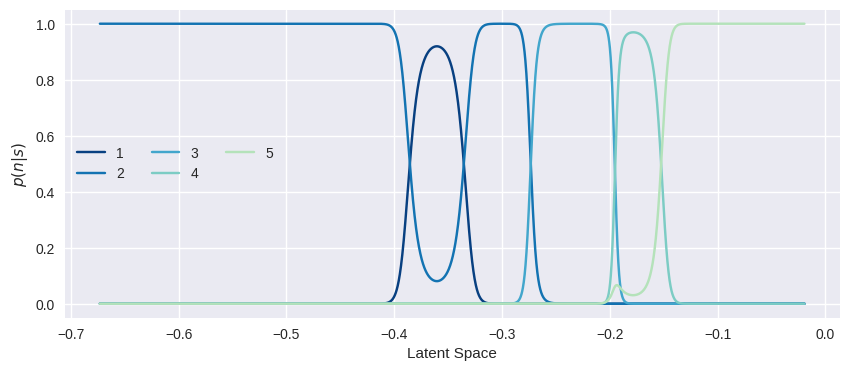

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integra

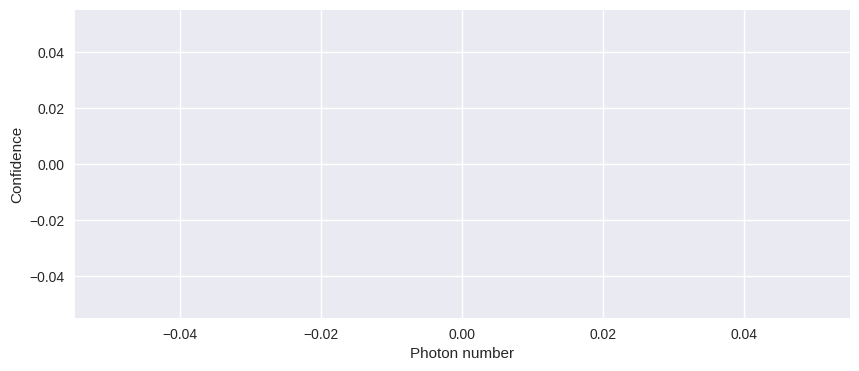

13.0
2.839924199084668


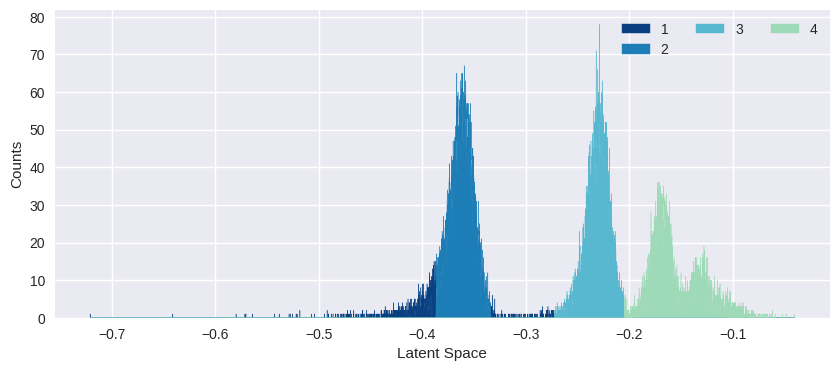

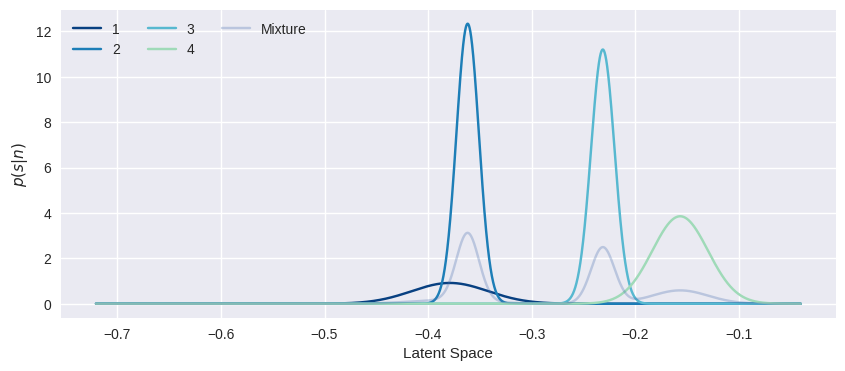

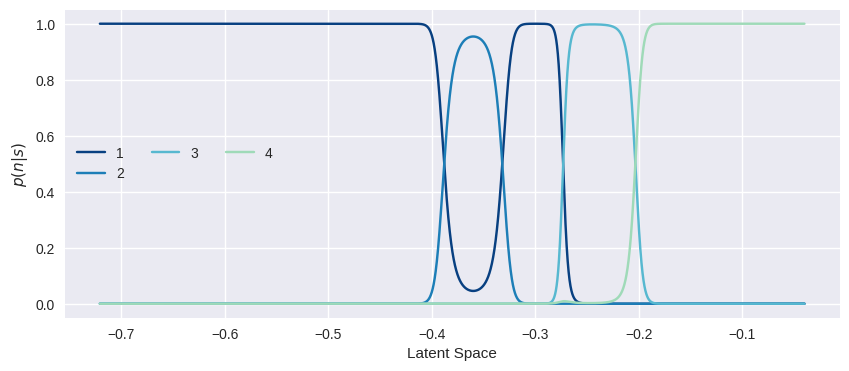

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the

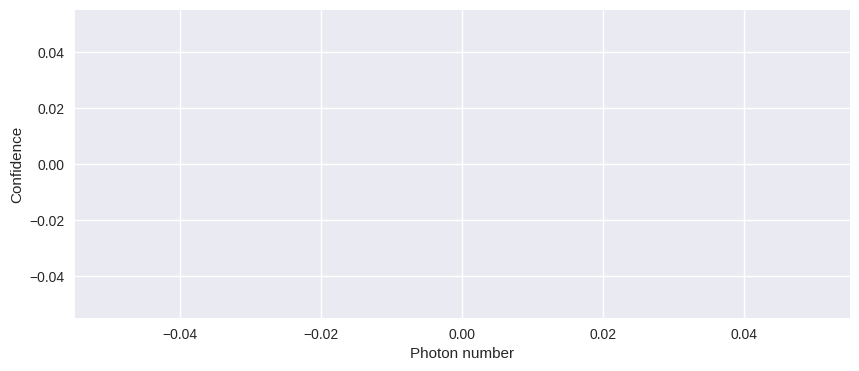

14.24
2.332218652904313


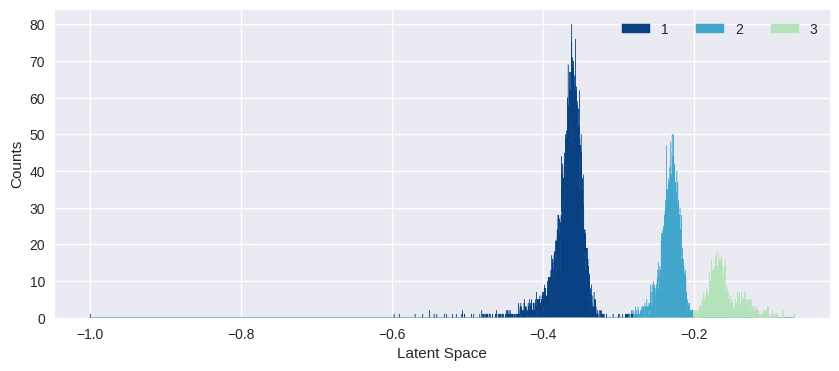

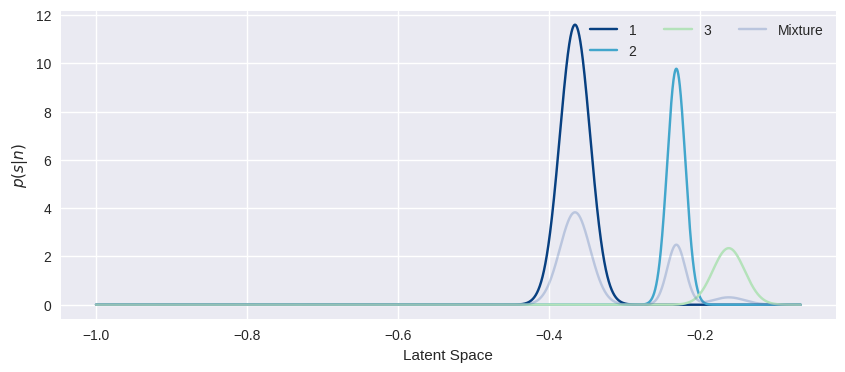

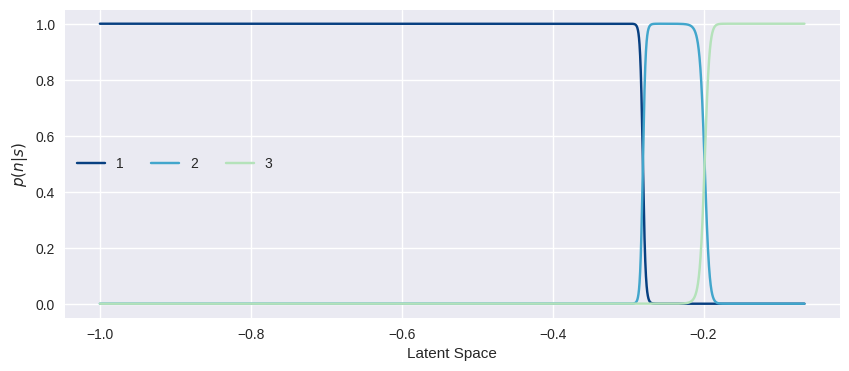

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


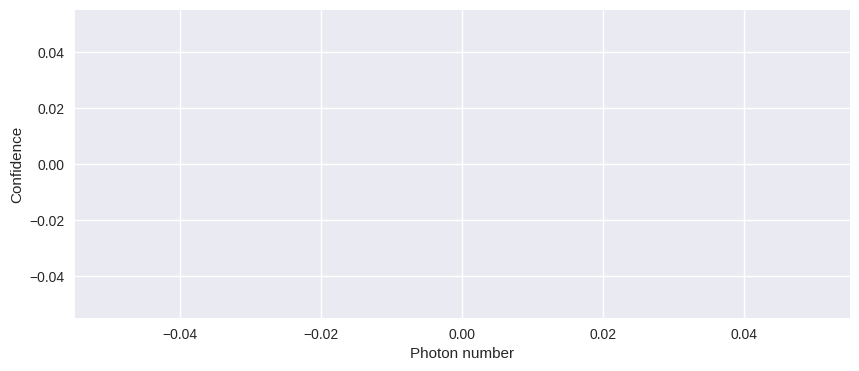

15.99
1.6426836238925406


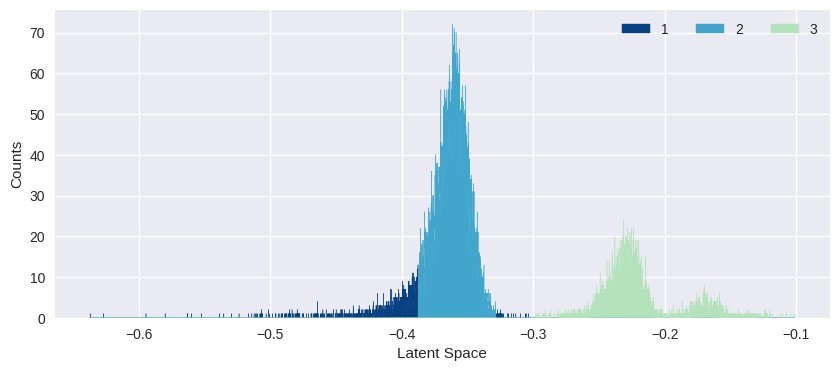

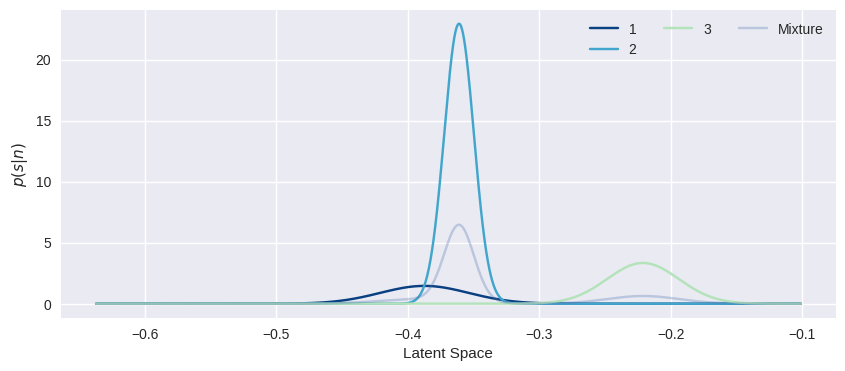

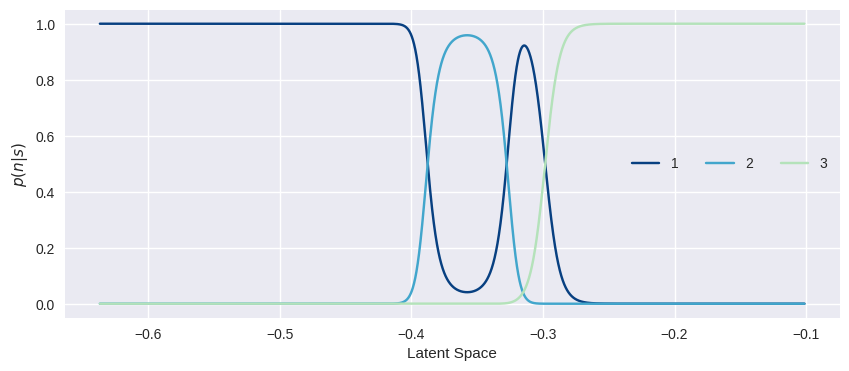

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:86: RuntimeWarning: invalid value encountered in divide
  integ = lambda s : self.p_sn_func(s)**2 * p_n_ / self.p_s_func(s)
/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/confidence.py:88: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  confidence[index] = quad(integ, -np.inf, np.inf)[0]


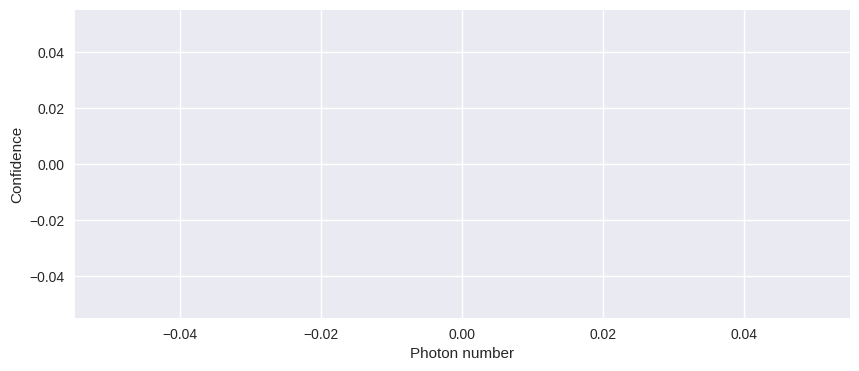

18.97
0.9188544611774662


In [4]:
decibel = []
g2 = []
average = []

method = PCA(n_components=1)
X_l = method.fit_transform(X)
X_l = (X_l-np.min(X_l)) / (np.max(X_l)-np.min(X_l))

conf = confidence(X_l,
                number_cluster = 6,
                flip = True, 
                size_plot = 10,
                label_shift = 1)

labels = conf.labels
number_cluster_list =[6, 6, 6, 5, 5, 5, 5, 4, 3, 3]

for index, key in enumerate(np.unique(decibel_samples)):
    
    condition = decibel_samples == key
    zeros_number = len(decibel_zeros[decibel_zeros == key])

    conf.fit(X_l[condition],
            number_cluster = number_cluster_list[index],
            flip = True, 
            label_dB = key)
    
    #labels_ = labels[condition]
    labels_ = np.concatenate([labels[condition]+1, np.zeros(zeros_number)])
    print(key)
    print(np.mean(labels_))

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

## Total

In [ ]:
conf.plot_all_confidence()
conf.plot_all_density(xlim=(-0.5,0))#xlim=(0.65,0.1)
conf.plot_total_density()
conf.plot_mean_cluster()

# dB evaluation

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB/10 )

In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -10], [1e4, 10]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt))
plt.scatter(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.show()
print(popt)

In [ ]:
import numpy.random as npr

average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 30_000) for i in average])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poisson statistic of Autoencoder

## Load

In [ ]:
X, decibel_samples, decibel_zeros = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', #, decibel_zeros
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)

In [ ]:
condition = np.min(X, axis=1) < -1.51
X = X[condition]
decibel_samples = decibel_samples[condition]

#condition = X[:,100] > -1.5
#X = X[condition]
#decibel_samples = decibel_samples[condition]

plot_traces(X)

## Confidence

In [ ]:
decibel = []
g2 = []
average = []

X = X[:,:1000]
#X = -1*X

X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(X, f'AutoencoderLog/{path_model}', filter=False, flip=False)

conf = confidence(X_l_AUTO,
                bw = [0.004],  #007
                number_cluster = 7,#0.1,
                bins_plot = 5_000,
                density_kernel='gaussian',
                flip = False, 
                skip = 30,
                size_plot = 10,
                scaling=30)

labels = conf.labels
#         [9.05,  9.5, 10.01,10.59, 11.25, 12.04, 13.0, 14.24, 15.99, 18.97
bw_list = [0.01]*10#[0.02, 0.01, 0.01, 0.012, 0.011, 0.01, 0.01, 0.015, 0.009, 0.008]     #[0.01]*10
min_prob_list = [6]*10#[0.02, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.05, 0.05, 0.05]
#min_prob_list = [0.01, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025]

for index, key in enumerate(np.unique(decibel_samples)):

    condition = decibel_samples == key
    zeros_number = len(decibel_zeros[decibel_zeros == key])

    conf.fit(X_l_AUTO[condition],
            bw = [bw_list[index]], 
            number_cluster = min_prob_list[index],
            bins_plot = 1000,
            density_kernel='gaussian',
            flip = False, 
            skip = 10,
            size_plot = 10,
            scaling=30,
            zeros_number=zeros_number,
            label_dB = key)
    
    labels_ = np.concatenate([labels[condition]+1, np.zeros(zeros_number)])
    print(key)
    print(np.mean(labels_))
    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

## Plot

In [ ]:
conf.plot_all_confidence()
conf.plot_all_density()
conf.plot_mean_cluster()

# dB

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB/10 )

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -10], [1e4, 10]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt))
plt.scatter(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.show()
print(popt)

In [ ]:
import numpy.random as npr

average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 25_000) for i in average])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poisson statistic of Max variance

## Load

In [ ]:
X, decibel_samples, decibel_zeros = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', #, decibel_zeros
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)

In [ ]:
#X = X[:,::20]
#X = savgol_filter(X, 50, 4)
cond = np.min(X, axis=1) < -1.5
X = X[cond]
decibel_samples = decibel_samples[cond]
plot_traces(X)

## Confidence

In [ ]:
decibel = []
g2 = []
average = []



index_max_var = np.argpartition(np.var(X, axis=0), -1)[-1:]
X_i_MAX = X[:, index_max_var]
X_l_MAX = X[:, index_max_var]

conf = confidence(X_l_MAX,
                bw = [0.0042], 
                min_cluster_prob = 1,
                bins_plot = 5_000,
                density_kernel='gaussian',
                flip = False, 
                skip = 5,
                size_plot = 10,
                scaling=30)

labels = conf.labels
#         [9.05,  9.5, 10.01,10.59, 11.25, 12.04, 13.0, 14.24, 15.99, 18.97
bw_list = [0.009, 0.009, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.0085] #gaussian 
#bw_list = [0.0092, 0.01, 0.011, 0.012, 0.011, 0.01, 0.01, 0.015, 0.009, 0.008] #gaussian 
min_prob_list = [0.1, 0.025, 0.25, 0.25, 0.25, 0.25, 0.25, 0.05, 0.05, 0.05] #gaussian
#min_prob_list = [0.01, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025]

for index, key in enumerate(np.unique(decibel_samples)):

    condition = decibel_samples == key
    zeros_number = len(decibel_zeros[decibel_zeros == key])

    conf.fit(X_l_MAX[condition],
            bw = [bw_list[index]], 
            min_cluster_prob = min_prob_list[index],
            bins_plot = 1000,
            density_kernel='gaussian',
            flip = False, 
            skip = 5,
            size_plot = 10,
            scaling=10,
            zeros_number=zeros_number,
            label_dB = key)
    
    labels_ = np.concatenate([labels[condition]+1, np.zeros(zeros_number)])
    print(key)
    print(np.mean(labels_))
    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

## Plot

In [ ]:
conf.plot_all_confidence()
conf.plot_all_density(xlim=(-1,0))
conf.plot_mean_cluster()
conf.plot_total_density()

# dB

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB/10 )

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -10], [1e4, 10]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt))
plt.scatter(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.show()
print(popt)


import numpy.random as npr

average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 30_000) for i in average])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()